# ***Introduction:***

As we saw in slides, There are a lot of different neural network models, which answer different computational/learning needs:

**_ Supevised learning** (classification, regression, time series, ...);

**_ Unsupervised learning** (clustering, representation learning,
self-organized maps, associative memories, ...)

And Now I want to work on one of the unsupervised models, Self organized maps or Kohonen Map or SOM.

***Self-Organizing Map*** is one of the common unsupervised neural network models (is a type of artificial neural network (ANN)). SOM has been widely used for clustering, dimension reduction, and feature detection and was inspired by biological models of neural systems from the 1970s, That first introduced by Professor Kohonen. For this reason, SOM also called Kohonen Map. It follows an unsupervised learning approach and trained its network through a competitive learning algorithm.

It has 2 layers. One input layer and the other is output layer. SOM differ from other artificial neural networks as they apply competitive learning as opposed to error-correction learning (such as backpropagation with gradient descent), and in the sense that they use a neighborhood function to preserve the topological properties of the input space.

Simply here we can see the evolution of the SOM:
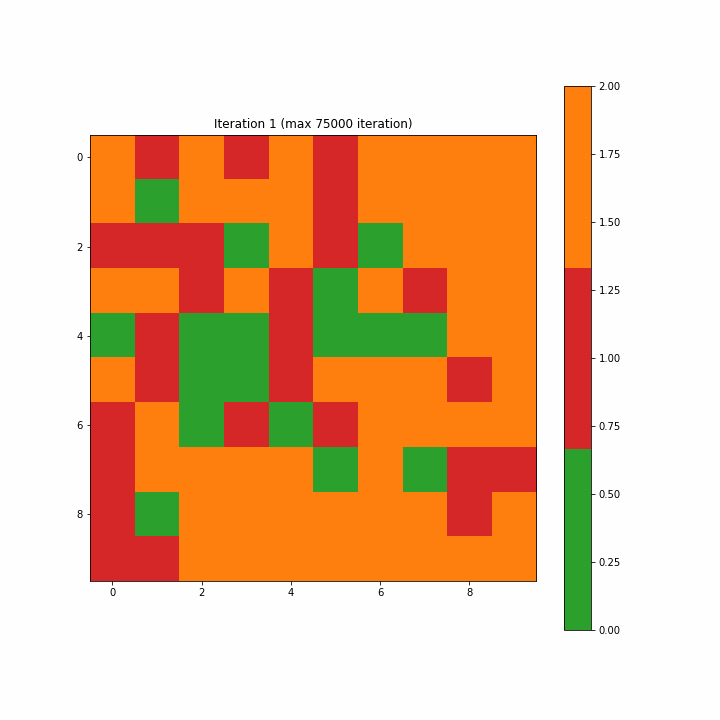


The SOM’s algorithm is relatively simple, but there may be some confusion at first sight and difficulties figuring out how to apply it in practice. It may be because SOM can be understood from multiple perspectives. It is like ***Principal Component Analysis (PCA)*** for dimensionality reduction and visualisation. SOM can also be considered a type of manifold learning that handles non-linear dimensionality reduction.


One of the questions that will come to our mind will be why should we use SOM?

Cause we use this model to map multidimensional data into lower-dimensional, which allows people to reduce complex problems for easy interpretation. By really simple method we can make all our works easy :))
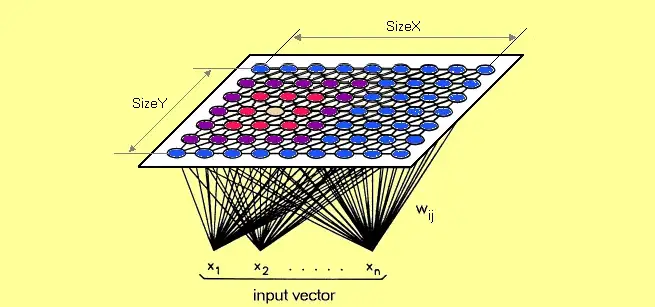

Each data point in the data set recognizes themselves by competeting for representation. SOM mapping steps starts from initializing the weight vectors. From there a sample vector is selected randomly and the map of weight vectors is searched to find which weight best represents that sample. Each weight vector has neighboring weights that are close to it. The weight that is chosen is rewarded by being able to become more like that randomly selected sample vector. The neighbors of that weight are also rewarded by being able to become more like the chosen sample vector. This allows the map to grow and form different shapes. Most generally, they form square/rectangular/hexagonal/L shapes in 2D feature space.

***The Self-Organising Map learning algorithm*** (online learning) can be represented in these steps:

1.   Each node’s weights are initialized.
2.   A vector is chosen at random from the set of training data.
3.   Every node is examined to calculate which one’s weights are most like the input vector. The winning node is commonly known as the Best Matching Unit (BMU).
4.   Then the neighbourhood of the BMU is calculated. The amount of neighbors decreases over time.
5.   The winning weight is rewarded with becoming more like the sample vector. The nighbors also become more like the sample vector. The closer a node is to the BMU, the more its weights get altered and the farther away the neighbor is from the BMU, the less it learns.
6.    Repeat step 2 for N iterations.

Best Matching Unit is a technique which calculates the distance from each weight to the sample vector, by running through all weight vectors. The weight with the shortest distance is the winner. There are numerous ways to determine the distance, however, the most commonly used method is the Euclidean Distance, and that’s what is used in the following implementation.

***Cons of Kohonen Maps:***

*   It does not build a generative model for the data, i.e, the model does not understand how data is created.
*   It does not behave so gently when using categorical data, even worse for mixed types data.
*  The time for preparing model is slow, hard to train against slowly evolving data  


# ***Implementation:***

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib as plt

#Import the dataset
#Using the dataset from kaggle: https://www.kaggle.com/datasets/ujjwal9/credit-card-applications
from google.colab import files
upload = files.upload()


Saving Credit_Card_Applications.csv to Credit_Card_Applications.csv


In [ ]:
df =pd.read_csv("Credit_Card_Applications.csv")
df.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [ ]:
X = df.iloc [: , :-1].values  #Independent variables
Y = df.iloc [: , -1].values   #Dependent variables

#Feature Scaling
from sklearn.preprocessing import MinMaxScaler
screen = MinMaxScaler(feature_range = (0,1))
X = screen.fit_transform(X)

In [ ]:
!pip install minisom

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for minisom: filename=MiniSom-2.3.0-py3-none-any.whl size=9016 sha256=1f1e81b65754d18d2c0eeda2473bbf2c48e6abc0d1401229fc2f05b74659cff2
  Stored in directory: /root/.cache/pip/wheels/d4/ca/4a/488772b0399fec45ff53132ed14c948dec4b30deee3a532f80
Successfully built minisom


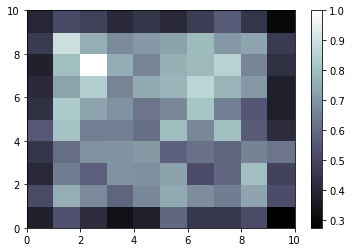

In [ ]:
#Import the SOM model
from minisom import MiniSom
#10 by 10 grid
Som = MiniSom(x = 10 , y = 10 , input_len = 15 , sigma = 1.0 , learning_rate = 0.5)
#Init the weight
Som.random_weights_init(X)
#Training the model
Som.train_random(data = X , num_iteration = 100)
#Making the self organization map
from pylab import bone, pcolor, colorbar , plot  , show
bone()
pcolor(Som.distance_map().T)
colorbar()
markers = ['o' , 's']
colors = ['r' , 'g']
for i, x in enumerate(X):
  w = Som.winner(x)
  plot(w[0] + 0.5 , w[1] + 0.5 )


The white color area is high potential fraud which we detect here.

In [ ]:
#Catch the potential Fraud
#Maping the winning node
mappings = Som.win_map(X)
#Catch the cheater
Frauds = np.concatenate((mappings[(7,9)] , mappings[(3,1)] , mappings[(5,1)]) , axis = 0)
#Rescale the value using inverse function
Frauds = screen.inverse_transform(Frauds)
Frauds

array([[1.5664793e+07, 0.0000000e+00, 1.7330000e+01, 9.5000000e+00,
        2.0000000e+00, 6.0000000e+00, 4.0000000e+00, 1.7500000e+00,
        0.0000000e+00, 1.0000000e+00, 1.0000000e+01, 1.0000000e+00,
        2.0000000e+00, 0.0000000e+00, 1.1000000e+01],
       [1.5670029e+07, 0.0000000e+00, 1.6920000e+01, 5.0000000e-01,
        2.0000000e+00, 3.0000000e+00, 4.0000000e+00, 1.6500000e-01,
        0.0000000e+00, 1.0000000e+00, 6.0000000e+00, 1.0000000e+00,
        2.0000000e+00, 2.4000000e+02, 3.6000000e+01],
       [1.5763579e+07, 0.0000000e+00, 1.6000000e+01, 1.6500000e-01,
        2.0000000e+00, 6.0000000e+00, 4.0000000e+00, 1.0000000e+00,
        0.0000000e+00, 1.0000000e+00, 2.0000000e+00, 1.0000000e+00,
        2.0000000e+00, 3.2000000e+02, 2.0000000e+00],
       [1.5662189e+07, 0.0000000e+00, 2.8580000e+01, 3.7500000e+00,
        2.0000000e+00, 8.0000000e+00, 4.0000000e+00, 2.5000000e-01,
        0.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        2.0000000e+00,